# 검사 설명서 기반 도메인 분석
---
## 목표: 검사 단위/기능 단위로 latent 도메인을 잡고, 도메인별 composite score 설계


## 1. 환경 설정


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("환경 설정 완료!")


환경 설정 완료!


## 2. 데이터 로드


In [2]:
# 데이터 로드
train_meta = pd.read_csv("./data/train.csv")
train_A_raw = pd.read_csv("./data/train/A.csv")
train_B_raw = pd.read_csv("./data/train/B.csv")

overall_risk = train_meta['Label'].mean()
print(f"전체 위험군 비율: {overall_risk:.4f}")
print(f"A검사 샘플: {len(train_A_raw)}, B검사 샘플: {len(train_B_raw)}")


전체 위험군 비율: 0.0289
A검사 샘플: 647241, B검사 샘플: 297526


## 3. 유틸 함수 정의 (기존과 동일)


In [3]:
def convert_age(val):
    if pd.isna(val):
        return np.nan
    try:
        base = int(str(val)[:-1])
        return base if str(val)[-1].lower() == "a" else base + 5
    except:
        return np.nan

def seq_mean(series):
    s = series.fillna("").astype(str)
    df = s.str.split(",", expand=True).replace("", np.nan).astype(float)
    return df.mean(axis=1)

def seq_std(series):
    s = series.fillna("").astype(str)
    df = s.str.split(",", expand=True).replace("", np.nan).astype(float)
    return df.std(axis=1)

def seq_rate(series, target="1"):
    def calc(x):
        if not x:
            return np.nan
        items = str(x).split(",")
        return items.count(str(target)) / len(items) if items else np.nan
    return series.fillna("").apply(calc)

def masked_mean(cond_series, val_series, mask_val):
    cond_df = cond_series.fillna("").str.split(",", expand=True).replace("", np.nan).astype(float)
    val_df = val_series.fillna("").str.split(",", expand=True).replace("", np.nan).astype(float)
    mask = (cond_df == mask_val)
    return val_df.where(mask).mean(axis=1)

print("유틸 함수 정의 완료!")


유틸 함수 정의 완료!


## 4. A검사 기본 피처 생성


In [4]:
# A검사 전처리
A_df = train_A_raw.copy()
A_df = A_df.merge(train_meta[['Test_id', 'Label']], on='Test_id', how='left')

# Age
A_df['Age_num'] = A_df['Age'].map(convert_age)
A_df['Age_z'] = (A_df['Age_num'] - A_df['Age_num'].mean()) / A_df['Age_num'].std()

# A1 (주의집중, 반응속도)
A_df['A1_resp_rate'] = seq_rate(A_df['A1-3'], '1')
A_df['A1_rt_mean'] = seq_mean(A_df['A1-4'])
A_df['A1_rt_std'] = seq_std(A_df['A1-4'])
A_df['A1_rt_cv'] = A_df['A1_rt_std'] / (A_df['A1_rt_mean'] + 1e-6)

# A4 (Stroop 과제)
A_df['A4_acc_rate'] = seq_rate(A_df['A4-3'], '1')
A_df['A4_rt_mean'] = seq_mean(A_df['A4-5'])
A_df['A4_stroop_diff'] = (
    masked_mean(A_df['A4-1'], A_df['A4-5'], 2) - 
    masked_mean(A_df['A4-1'], A_df['A4-5'], 1)
)

# A5 (변화 탐지)
A_df['A5_acc_rate'] = seq_rate(A_df['A5-2'], '1')
A_df['A5_acc_nonchange'] = masked_mean(A_df['A5-1'], A_df['A5-2'], 1)
A_df['A5_acc_change'] = pd.concat([
    masked_mean(A_df['A5-1'], A_df['A5-2'], 2),
    masked_mean(A_df['A5-1'], A_df['A5-2'], 3),
    masked_mean(A_df['A5-1'], A_df['A5-2'], 4)
], axis=1).mean(axis=1)
A_df['A5_change_nonchange_gap'] = A_df['A5_acc_change'] - A_df['A5_acc_nonchange']

# A6, A7, A9 종합 점수
a6_cols = [c for c in A_df.columns if c.startswith('A6-')]
a7_cols = [c for c in A_df.columns if c.startswith('A7-')]
a9_cols = [c for c in A_df.columns if c.startswith('A9-')]

if a6_cols:
    A_df['A6_total'] = A_df[a6_cols].sum(axis=1)
if a7_cols:
    A_df['A7_total'] = A_df[a7_cols].sum(axis=1)
if a9_cols:
    A_df['A9_total'] = A_df[a9_cols].sum(axis=1)

# 인지/정서 점수
A_df['CogScore_A'] = 0
if 'A6_total' in A_df.columns:
    A_df['CogScore_A'] += A_df['A6_total']
if 'A7_total' in A_df.columns:
    A_df['CogScore_A'] += A_df['A7_total']
if 'A9-4' in A_df.columns:
    A_df['CogScore_A'] += A_df['A9-4'].fillna(0)

A_df['EmoScore_A'] = 0
for col in ['A9-1', 'A9-2', 'A9-5']:
    if col in A_df.columns:
        A_df['EmoScore_A'] += A_df[col].fillna(0)

# A8, A9 추가 점수
if all(c in A_df.columns for c in ['A8-1', 'A8-2']):
    A_df['A8_Validity_Score'] = A_df['A8-1'].fillna(0) + A_df['A8-2'].fillna(0)

a9_emo_cols = ['A9-1', 'A9-2', 'A9-3', 'A9-5']
if all(c in A_df.columns for c in a9_emo_cols):
    A_df['A9_Emotional_Score'] = A_df[a9_emo_cols].fillna(0).sum(axis=1)

print(f"A검사 피처 생성 완료: {A_df.shape}")
print(f"Label 결측: {A_df['Label'].isnull().sum()}")


A검사 피처 생성 완료: (647241, 58)
Label 결측: 0


In [23]:
# B검사 전처리
B_df = train_B_raw.copy()
B_df = B_df.merge(train_meta[['Test_id', 'Label']], on='Test_id', how='left')

# Age
B_df['Age_num'] = B_df['Age'].map(convert_age)
B_df['Age_z'] = (B_df['Age_num'] - B_df['Age_num'].mean()) / B_df['Age_num'].std()

# B3, B4 (주의집중, Stroop-like)
B_df['B3_acc_rate'] = seq_rate(B_df['B3-1'], '1')
B_df['B3_rt_mean'] = seq_mean(B_df['B3-2'])
B_df['B3_rt_std'] = seq_std(B_df['B3-2'])

B_df['B4_acc_rate'] = seq_rate(B_df['B4-1'], '1')
B_df['B4_rt_mean'] = seq_mean(B_df['B4-2'])
B_df['B4_rt_std'] = seq_std(B_df['B4-2'])

# B9, B10 (지속 주의력, 이중과제)
if all(c in B_df.columns for c in ['B9-1', 'B9-2', 'B9-3', 'B9-4', 'B9-5']):
    B9_AUD_TARGET = 15.0
    B9_AUD_DIST = 35.0
    B_df['B9_aud_overall_acc'] = (
        (B_df['B9-1'].astype(float) + B_df['B9-4'].astype(float)) / (B9_AUD_TARGET + B9_AUD_DIST)
    )
    B_df['B9_vis_err_rate'] = B_df['B9-5'].astype(float) / 32.0

if all(c in B_df.columns for c in ['B10-1', 'B10-2', 'B10-3', 'B10-4', 'B10-5']):
    B10_AUD_TARGET = 20.0
    B10_AUD_DIST = 60.0
    B_df['B10_aud_overall_acc'] = (
        (B_df['B10-1'].astype(float) + B_df['B10-4'].astype(float)) / (B10_AUD_TARGET + B10_AUD_DIST)
    )
    B_df['B10_vis1_err_rate'] = B_df['B10-5'].astype(float) / 52.0
    
    if 'B9_aud_overall_acc' in B_df.columns:
        B_df['B10_multitask_cost_aud'] = B_df['B10_aud_overall_acc'] - B_df['B9_aud_overall_acc']
    if 'B9_vis_err_rate' in B_df.columns:
        B_df['B10_multitask_cost_vis'] = B_df['B10_vis1_err_rate'] - B_df['B9_vis_err_rate']

# RiskScore_B (script04 기반)
eps = 1e-6
B_df['B4_rt_cv'] = B_df['B4_rt_std'] / (B_df['B4_rt_mean'] + eps)
B_df['B3_speed_acc_tradeoff'] = B_df['B3_rt_mean'] / (B_df['B3_acc_rate'] + eps)
B_df['B4_speed_acc_tradeoff'] = B_df['B4_rt_mean'] / (B_df['B4_acc_rate'] + eps)

B_df['RiskScore_B'] = (
    0.25 * B_df['B4_rt_cv'].fillna(0) +
    0.25 * (1 - B_df['B3_acc_rate'].fillna(0)) +
    0.25 * (1 - B_df['B4_acc_rate'].fillna(0)) +
    0.25 * B_df['B3_speed_acc_tradeoff'].fillna(0)
)

print(f"B검사 피처 생성 완료: {B_df.shape}")
print(f"Label 결측: {B_df['Label'].isnull().sum()}")


B검사 피처 생성 완료: (297526, 50)
Label 결측: 0


## 6. 도메인별 Composite Score 설계 및 생성

### A검사 도메인:
1. **PerceptualSpeed_A**: 지각·예측/운동 속도 (A1, A2, A3 RT 관련)
2. **SelectiveAttention_A**: 선택적 주의 / 억제 (A3 valid/invalid, A4 Stroop)
3. **WorkingMemory_A**: 시각 작업기억/변화탐지 (A5)
4. **CognitiveAbility_A**: 지능/시지각 추론 (A6, A7)
5. **EmotionalRisk_A**: 정신적 민첩성·성격·정서/스트레스 (A8, A9)


In [24]:
def normalize_features(df, features, method='zscore'):
    """
    여러 피처를 정규화하여 결합
    
    Parameters:
    -----------
    df : DataFrame
    features : list - 정규화할 피처명 리스트
    method : str - 'zscore' or 'minmax'
    
    Returns:
    --------
    DataFrame - 정규화된 피처들
    """
    result = pd.DataFrame(index=df.index)
    
    for feat in features:
        if feat in df.columns:
            values = df[feat].fillna(df[feat].median())
            if method == 'zscore':
                mean_val = values.mean()
                std_val = values.std()
                if std_val > 0:
                    result[feat] = (values - mean_val) / std_val
                else:
                    result[feat] = 0
            elif method == 'minmax':
                min_val = values.min()
                max_val = values.max()
                if max_val > min_val:
                    result[feat] = (values - min_val) / (max_val - min_val)
                else:
                    result[feat] = 0
    
    return result

print("정규화 함수 정의 완료!")


정규화 함수 정의 완료!


In [7]:
# ===== A검사 도메인 Composite Score 생성 =====

print("="*80)
print("[A검사] 도메인별 Composite Score 생성")
print("="*80 + "\n")

# 1. PerceptualSpeed_A: 지각·예측/운동 속도
# A1_rt_mean, A4_rt_mean 등 RT 관련 피처 (낮을수록 좋음 → 음수로 변환)
perceptual_speed_features = ['A1_rt_mean', 'A4_rt_mean']
if all(f in A_df.columns for f in perceptual_speed_features):
    normalized = normalize_features(A_df, perceptual_speed_features, method='zscore')
    # RT는 낮을수록 좋으므로 음수로 변환
    A_df['PerceptualSpeed_A'] = -normalized[perceptual_speed_features].mean(axis=1)
    print(f"✅ PerceptualSpeed_A 생성 완료 (피처: {perceptual_speed_features})")
else:
    print(f"⚠️  PerceptualSpeed_A 피처 부족: {perceptual_speed_features}")

# 2. SelectiveAttention_A: 선택적 주의 / 억제
# A4_acc_rate (높을수록 좋음), A4_stroop_diff (낮을수록 좋음 → 음수), A1_resp_rate
selective_attention_features = ['A4_acc_rate', 'A1_resp_rate']
if all(f in A_df.columns for f in selective_attention_features):
    normalized = normalize_features(A_df, selective_attention_features, method='zscore')
    base_score = normalized[selective_attention_features].mean(axis=1)
    # A4_stroop_diff는 낮을수록 좋으므로 음수로 변환
    if 'A4_stroop_diff' in A_df.columns:
        stroop_norm = normalize_features(A_df, ['A4_stroop_diff'], method='zscore')
        A_df['SelectiveAttention_A'] = base_score - stroop_norm['A4_stroop_diff']
    else:
        A_df['SelectiveAttention_A'] = base_score
    print(f"✅ SelectiveAttention_A 생성 완료 (피처: {selective_attention_features} + A4_stroop_diff)")
else:
    print(f"⚠️  SelectiveAttention_A 피처 부족: {selective_attention_features}")

# 3. WorkingMemory_A: 시각 작업기억/변화탐지
# A5_acc_change, A5_change_nonchange_gap (높을수록 좋음)
working_memory_features = ['A5_acc_change', 'A5_change_nonchange_gap']
if all(f in A_df.columns for f in working_memory_features):
    normalized = normalize_features(A_df, working_memory_features, method='zscore')
    A_df['WorkingMemory_A'] = normalized[working_memory_features].mean(axis=1)
    print(f"✅ WorkingMemory_A 생성 완료 (피처: {working_memory_features})")
else:
    print(f"⚠️  WorkingMemory_A 피처 부족: {working_memory_features}")

# 4. CognitiveAbility_A: 지능/시지각 추론
# CogScore_A 사용 (이미 생성됨)
if 'CogScore_A' in A_df.columns:
    # Z-normalize
    cog_mean = A_df['CogScore_A'].mean()
    cog_std = A_df['CogScore_A'].std()
    if cog_std > 0:
        A_df['CognitiveAbility_A'] = (A_df['CogScore_A'] - cog_mean) / cog_std
    else:
        A_df['CognitiveAbility_A'] = 0
    print(f"✅ CognitiveAbility_A 생성 완료 (피처: CogScore_A)")
else:
    print(f"⚠️  CognitiveAbility_A 피처 부족: CogScore_A")

# 5. EmotionalRisk_A: 정신적 민첩성·성격·정서/스트레스
# A8_Validity_Score (높을수록 나쁨 → 음수), A9_Emotional_Score (높을수록 나쁨 → 음수)
emotional_features = []
if 'A8_Validity_Score' in A_df.columns:
    emotional_features.append('A8_Validity_Score')
if 'A9_Emotional_Score' in A_df.columns:
    emotional_features.append('A9_Emotional_Score')

if len(emotional_features) > 0:
    normalized = normalize_features(A_df, emotional_features, method='zscore')
    # 높을수록 나쁨이므로 음수로 변환
    A_df['EmotionalRisk_A'] = -normalized[emotional_features].mean(axis=1)
    print(f"✅ EmotionalRisk_A 생성 완료 (피처: {emotional_features})")
else:
    print(f"⚠️  EmotionalRisk_A 피처 부족")

print("\n" + "="*80)
print("✅ A검사 도메인 Composite Score 생성 완료!")
print("="*80)


[A검사] 도메인별 Composite Score 생성

✅ PerceptualSpeed_A 생성 완료 (피처: ['A1_rt_mean', 'A4_rt_mean'])
✅ SelectiveAttention_A 생성 완료 (피처: ['A4_acc_rate', 'A1_resp_rate'] + A4_stroop_diff)
✅ WorkingMemory_A 생성 완료 (피처: ['A5_acc_change', 'A5_change_nonchange_gap'])
✅ CognitiveAbility_A 생성 완료 (피처: CogScore_A)
✅ EmotionalRisk_A 생성 완료 (피처: ['A8_Validity_Score', 'A9_Emotional_Score'])

✅ A검사 도메인 Composite Score 생성 완료!


In [8]:
# ===== B검사 도메인 Composite Score 생성 =====

print("="*80)
print("[B검사] 도메인별 Composite Score 생성")
print("="*80 + "\n")

# 1. SelectiveAttention_B: 선택적 주의/억제
# B4_acc_rate (높을수록 좋음), B4_rt_mean (낮을수록 좋음 → 음수)
selective_attention_b_features = ['B4_acc_rate']
if all(f in B_df.columns for f in selective_attention_b_features):
    normalized = normalize_features(B_df, selective_attention_b_features, method='zscore')
    base_score = normalized[selective_attention_b_features].mean(axis=1)
    # B4_rt_mean은 낮을수록 좋으므로 음수로 변환
    if 'B4_rt_mean' in B_df.columns:
        rt_norm = normalize_features(B_df, ['B4_rt_mean'], method='zscore')
        B_df['SelectiveAttention_B'] = base_score - rt_norm['B4_rt_mean']
    else:
        B_df['SelectiveAttention_B'] = base_score
    print(f"✅ SelectiveAttention_B 생성 완료 (피처: {selective_attention_b_features} + B4_rt_mean)")
else:
    print(f"⚠️  SelectiveAttention_B 피처 부족: {selective_attention_b_features}")

# 2. ReactionSpeed_B: 시-운동 반응 속도
# B3_rt_mean, B4_rt_mean (낮을수록 좋음 → 음수)
reaction_speed_features = ['B3_rt_mean', 'B4_rt_mean']
if all(f in B_df.columns for f in reaction_speed_features):
    normalized = normalize_features(B_df, reaction_speed_features, method='zscore')
    # RT는 낮을수록 좋으므로 음수로 변환
    B_df['ReactionSpeed_B'] = -normalized[reaction_speed_features].mean(axis=1)
    print(f"✅ ReactionSpeed_B 생성 완료 (피처: {reaction_speed_features})")
else:
    print(f"⚠️  ReactionSpeed_B 피처 부족: {reaction_speed_features}")

# 3. MultitaskAbility_B: 지속 주의 + multitask cost
# B9_aud_overall_acc (높을수록 좋음), B10_multitask_cost_aud (낮을수록 좋음 → 음수)
multitask_features = []
if 'B9_aud_overall_acc' in B_df.columns:
    multitask_features.append('B9_aud_overall_acc')
if 'B10_multitask_cost_aud' in B_df.columns:
    multitask_features.append('B10_multitask_cost_aud')

if len(multitask_features) > 0:
    normalized = normalize_features(B_df, multitask_features, method='zscore')
    # B10_multitask_cost_aud는 낮을수록 좋으므로 음수로 변환
    if 'B10_multitask_cost_aud' in multitask_features:
        cost_idx = multitask_features.index('B10_multitask_cost_aud')
        normalized.iloc[:, cost_idx] = -normalized.iloc[:, cost_idx]
    B_df['MultitaskAbility_B'] = normalized[multitask_features].mean(axis=1)
    print(f"✅ MultitaskAbility_B 생성 완료 (피처: {multitask_features})")
else:
    print(f"⚠️  MultitaskAbility_B 피처 부족")

# 4. RiskScore_B: 통합 risk index (이미 생성됨, Z-normalize)
if 'RiskScore_B' in B_df.columns:
    risk_mean = B_df['RiskScore_B'].mean()
    risk_std = B_df['RiskScore_B'].std()
    if risk_std > 0:
        # RiskScore는 높을수록 나쁨이므로 음수로 변환
        B_df['RiskScore_B_norm'] = -(B_df['RiskScore_B'] - risk_mean) / risk_std
    else:
        B_df['RiskScore_B_norm'] = 0
    print(f"✅ RiskScore_B_norm 생성 완료 (피처: RiskScore_B)")
else:
    print(f"⚠️  RiskScore_B 피처 부족")

print("\n" + "="*80)
print("✅ B검사 도메인 Composite Score 생성 완료!")
print("="*80)


[B검사] 도메인별 Composite Score 생성

✅ SelectiveAttention_B 생성 완료 (피처: ['B4_acc_rate'] + B4_rt_mean)
✅ ReactionSpeed_B 생성 완료 (피처: ['B3_rt_mean', 'B4_rt_mean'])
✅ MultitaskAbility_B 생성 완료 (피처: ['B9_aud_overall_acc', 'B10_multitask_cost_aud'])
✅ RiskScore_B_norm 생성 완료 (피처: RiskScore_B)

✅ B검사 도메인 Composite Score 생성 완료!


## 7. Age-normed Z-score 생성

나이 bin별로 mean/std를 구해서 동연령 대비 위치를 나타내는 피처 생성


In [9]:
def create_age_bin(age_num):
    """나이를 bin으로 변환"""
    if pd.isna(age_num):
        return 'Unknown'
    elif age_num < 50:
        return '<50'
    elif age_num < 60:
        return '50-59'
    elif age_num < 70:
        return '60-69'
    else:
        return '70+'

def create_age_normed_score(df, feature_name, age_col='Age_num', label_col='Label'):
    """
    나이 bin별로 정규화된 점수 생성
    
    Parameters:
    -----------
    df : DataFrame
    feature_name : str - 정규화할 피처명
    age_col : str - 나이 컬럼명
    label_col : str - 타겟 컬럼명
    
    Returns:
    --------
    Series - age-normed z-score
    """
    if feature_name not in df.columns:
        return pd.Series(np.nan, index=df.index)
    
    df = df.copy()
    df['Age_bin'] = df[age_col].apply(create_age_bin)
    
    result = pd.Series(np.nan, index=df.index)
    
    for age_bin in df['Age_bin'].unique():
        if age_bin == 'Unknown':
            continue
        mask = df['Age_bin'] == age_bin
        values = df.loc[mask, feature_name].fillna(df.loc[mask, feature_name].median())
        
        mean_val = values.mean()
        std_val = values.std()
        
        if std_val > 0:
            result.loc[mask] = (df.loc[mask, feature_name].fillna(mean_val) - mean_val) / std_val
        else:
            result.loc[mask] = 0
    
    return result

print("Age-normed score 함수 정의 완료!")


Age-normed score 함수 정의 완료!


In [10]:
# ===== A검사 Age-normed Score 생성 =====

print("="*80)
print("[A검사] Age-normed Z-score 생성")
print("="*80 + "\n")

# 주요 피처들에 대해 age-normed score 생성
age_normed_features_A = [
    'CogScore_A',
    'A4_acc_rate',
    'A4_stroop_diff',
    'A1_rt_mean',
    'A5_change_nonchange_gap',
    'PerceptualSpeed_A',
    'SelectiveAttention_A',
    'WorkingMemory_A',
    'CognitiveAbility_A',
    'EmotionalRisk_A'
]

for feat in age_normed_features_A:
    if feat in A_df.columns:
        age_normed_name = f"{feat}_age_normed"
        A_df[age_normed_name] = create_age_normed_score(A_df, feat)
        print(f"✅ {age_normed_name} 생성 완료")
    else:
        print(f"⚠️  {feat} 피처 없음")

print("\n" + "="*80)
print("✅ A검사 Age-normed Score 생성 완료!")
print("="*80)


[A검사] Age-normed Z-score 생성

✅ CogScore_A_age_normed 생성 완료
✅ A4_acc_rate_age_normed 생성 완료
✅ A4_stroop_diff_age_normed 생성 완료
✅ A1_rt_mean_age_normed 생성 완료
✅ A5_change_nonchange_gap_age_normed 생성 완료
✅ PerceptualSpeed_A_age_normed 생성 완료
✅ SelectiveAttention_A_age_normed 생성 완료
✅ WorkingMemory_A_age_normed 생성 완료
✅ CognitiveAbility_A_age_normed 생성 완료
✅ EmotionalRisk_A_age_normed 생성 완료

✅ A검사 Age-normed Score 생성 완료!


In [11]:
# ===== B검사 Age-normed Score 생성 =====

print("="*80)
print("[B검사] Age-normed Z-score 생성")
print("="*80 + "\n")

# 주요 피처들에 대해 age-normed score 생성
age_normed_features_B = [
    'B4_acc_rate',
    'B4_rt_mean',
    'RiskScore_B',
    'B10_multitask_cost_aud',
    'SelectiveAttention_B',
    'ReactionSpeed_B',
    'MultitaskAbility_B',
    'RiskScore_B_norm'
]

for feat in age_normed_features_B:
    if feat in B_df.columns:
        age_normed_name = f"{feat}_age_normed"
        B_df[age_normed_name] = create_age_normed_score(B_df, feat)
        print(f"✅ {age_normed_name} 생성 완료")
    else:
        print(f"⚠️  {feat} 피처 없음")

print("\n" + "="*80)
print("✅ B검사 Age-normed Score 생성 완료!")
print("="*80)


[B검사] Age-normed Z-score 생성

✅ B4_acc_rate_age_normed 생성 완료
✅ B4_rt_mean_age_normed 생성 완료
✅ RiskScore_B_age_normed 생성 완료
✅ B10_multitask_cost_aud_age_normed 생성 완료
✅ SelectiveAttention_B_age_normed 생성 완료
✅ ReactionSpeed_B_age_normed 생성 완료
✅ MultitaskAbility_B_age_normed 생성 완료
✅ RiskScore_B_norm_age_normed 생성 완료

✅ B검사 Age-normed Score 생성 완료!


## 8. Rare Extreme Flag 생성 및 분석

커버리지가 작지만 위험비율이 매우 높은 flag 생성


In [12]:
def analyze_flag_risk(df, flag_col, label_col='Label', overall_risk=None):
    """
    Flag의 위험비율 분석
    
    Returns:
    --------
    dict - 위험비율, 커버리지, risk ratio 등
    """
    if flag_col not in df.columns:
        return None
    
    if overall_risk is None:
        overall_risk = df[label_col].mean()
    
    risk_by_flag = df.groupby(flag_col)[label_col].agg(['mean', 'count'])
    
    if 1 not in risk_by_flag.index:
        return None
    
    flag_risk = risk_by_flag.loc[1, 'mean']
    flag_count = risk_by_flag.loc[1, 'count']
    flag_coverage = flag_count / len(df) * 100
    risk_ratio = flag_risk / overall_risk if overall_risk > 0 else np.nan
    
    return {
        'flag_risk': flag_risk,
        'flag_count': flag_count,
        'flag_coverage': flag_coverage,
        'risk_ratio': risk_ratio,
        'overall_risk': overall_risk
    }

print("Flag 분석 함수 정의 완료!")


Flag 분석 함수 정의 완료!


In [13]:
# ===== A검사 Rare Extreme Flag 생성 =====

print("="*80)
print("[A검사] Rare Extreme Flag 생성")
print("="*80 + "\n")

# 1. A4_low_acc_flag: A4_acc_rate < 0.8
A_df['A4_low_acc_flag'] = (A_df['A4_acc_rate'] < 0.8).astype(int)

# 2. Old_and_low_A4: Age>=60 & A4_low_acc_flag
A_df['Old_and_low_A4'] = (
    (A_df['Age_num'] >= 60) & (A_df['A4_low_acc_flag'] == 1)
).astype(int)

# 3. A_low_cog_flag: CogScore_A < 하위 25%
if 'CogScore_A' in A_df.columns:
    cog_threshold = A_df['CogScore_A'].quantile(0.25)
    A_df['A_low_cog_flag'] = (A_df['CogScore_A'] < cog_threshold).astype(int)

# 4. A4_high_stroop_flag: A4_stroop_diff > 상위 25%
if 'A4_stroop_diff' in A_df.columns:
    stroop_threshold = A_df['A4_stroop_diff'].quantile(0.75)
    A_df['A4_high_stroop_flag'] = (A_df['A4_stroop_diff'] > stroop_threshold).astype(int)

# 5. A1_slow_rt_flag: A1_rt_mean > 상위 25%
if 'A1_rt_mean' in A_df.columns:
    rt_threshold = A_df['A1_rt_mean'].quantile(0.75)
    A_df['A1_slow_rt_flag'] = (A_df['A1_rt_mean'] > rt_threshold).astype(int)

# 6. A8_high_validity_flag: A8_Validity_Score > 상위 10%
if 'A8_Validity_Score' in A_df.columns:
    validity_threshold = A_df['A8_Validity_Score'].quantile(0.90)
    A_df['A8_high_validity_flag'] = (A_df['A8_Validity_Score'] > validity_threshold).astype(int)

# 7. A9_high_emotional_flag: A9_Emotional_Score > 상위 10%
if 'A9_Emotional_Score' in A_df.columns:
    emotional_threshold = A_df['A9_Emotional_Score'].quantile(0.90)
    A_df['A9_high_emotional_flag'] = (A_df['A9_Emotional_Score'] > emotional_threshold).astype(int)

# Flag 분석
flags_A = [
    'A4_low_acc_flag',
    'Old_and_low_A4',
    'A_low_cog_flag',
    'A4_high_stroop_flag',
    'A1_slow_rt_flag',
    'A8_high_validity_flag',
    'A9_high_emotional_flag'
]

print("\n[각 Flag의 위험비율 분석]\n")
flag_results_A = {}
for flag in flags_A:
    if flag in A_df.columns:
        result = analyze_flag_risk(A_df, flag, overall_risk=overall_risk)
        if result:
            flag_results_A[flag] = result
            print(f"{flag}:")
            print(f"  → 위험비율: {result['flag_risk']:.4f} (전체: {result['overall_risk']:.4f})")
            print(f"  → 커버리지: {result['flag_count']} / {len(A_df)} ({result['flag_coverage']:.2f}%)")
            print(f"  → Risk Ratio: {result['risk_ratio']:.2f}x")
            print()

print("="*80)
print("✅ A검사 Rare Extreme Flag 생성 완료!")
print("="*80)


[A검사] Rare Extreme Flag 생성


[각 Flag의 위험비율 분석]

A4_low_acc_flag:
  → 위험비율: 0.0601 (전체: 0.0289)
  → 커버리지: 416 / 647241 (0.06%)
  → Risk Ratio: 2.08x

Old_and_low_A4:
  → 위험비율: 0.0922 (전체: 0.0289)
  → 커버리지: 206 / 647241 (0.03%)
  → Risk Ratio: 3.19x

A_low_cog_flag:
  → 위험비율: 0.0320 (전체: 0.0289)
  → 커버리지: 161351 / 647241 (24.93%)
  → Risk Ratio: 1.11x

A4_high_stroop_flag:
  → 위험비율: 0.0253 (전체: 0.0289)
  → 커버리지: 161634 / 647241 (24.97%)
  → Risk Ratio: 0.88x

A1_slow_rt_flag:
  → 위험비율: 0.0239 (전체: 0.0289)
  → 커버리지: 161781 / 647241 (25.00%)
  → Risk Ratio: 0.83x

A8_high_validity_flag:
  → 위험비율: 0.0280 (전체: 0.0289)
  → 커버리지: 42120 / 647241 (6.51%)
  → Risk Ratio: 0.97x

A9_high_emotional_flag:
  → 위험비율: 0.0284 (전체: 0.0289)
  → 커버리지: 64555 / 647241 (9.97%)
  → Risk Ratio: 0.98x

✅ A검사 Rare Extreme Flag 생성 완료!


In [14]:
# ===== B검사 Rare Extreme Flag 생성 =====

print("="*80)
print("[B검사] Rare Extreme Flag 생성")
print("="*80 + "\n")

# 1. B4_low_acc_flag: B4_acc_rate < 0.85
B_df['B4_low_acc_flag'] = (B_df['B4_acc_rate'] < 0.85).astype(int)

# 2. B4_slow_rt_flag: B4_rt_mean > 상위 25%
if 'B4_rt_mean' in B_df.columns:
    b4_rt_threshold = B_df['B4_rt_mean'].quantile(0.75)
    B_df['B4_slow_rt_flag'] = (B_df['B4_rt_mean'] > b4_rt_threshold).astype(int)

# 3. B_high_risk_flag: RiskScore_B > 상위 25%
if 'RiskScore_B' in B_df.columns:
    risk_threshold = B_df['RiskScore_B'].quantile(0.75)
    B_df['B_high_risk_flag'] = (B_df['RiskScore_B'] > risk_threshold).astype(int)

# 4. B10_extreme_multitask_flag: B10_multitask_cost_aud > 상위 5% 또는 < 하위 5%
if 'B10_multitask_cost_aud' in B_df.columns:
    cost_q95 = B_df['B10_multitask_cost_aud'].quantile(0.95)
    cost_q05 = B_df['B10_multitask_cost_aud'].quantile(0.05)
    B_df['B10_extreme_multitask_flag'] = (
        (B_df['B10_multitask_cost_aud'] > cost_q95) | 
        (B_df['B10_multitask_cost_aud'] < cost_q05)
    ).astype(int)

# 5. Old_and_low_B4: Age>=60 & B4_low_acc_flag
B_df['Old_and_low_B4'] = (
    (B_df['Age_num'] >= 60) & (B_df['B4_low_acc_flag'] == 1)
).astype(int)

# Flag 분석
flags_B = [
    'B4_low_acc_flag',
    'B4_slow_rt_flag',
    'B_high_risk_flag',
    'B10_extreme_multitask_flag',
    'Old_and_low_B4'
]

print("\n[각 Flag의 위험비율 분석]\n")
flag_results_B = {}
for flag in flags_B:
    if flag in B_df.columns:
        result = analyze_flag_risk(B_df, flag, overall_risk=overall_risk)
        if result:
            flag_results_B[flag] = result
            print(f"{flag}:")
            print(f"  → 위험비율: {result['flag_risk']:.4f} (전체: {result['overall_risk']:.4f})")
            print(f"  → 커버리지: {result['flag_count']} / {len(B_df)} ({result['flag_coverage']:.2f}%)")
            print(f"  → Risk Ratio: {result['risk_ratio']:.2f}x")
            print()

print("="*80)
print("✅ B검사 Rare Extreme Flag 생성 완료!")
print("="*80)


[B검사] Rare Extreme Flag 생성


[각 Flag의 위험비율 분석]

B4_low_acc_flag:
  → 위험비율: 0.0423 (전체: 0.0289)
  → 커버리지: 297523 / 297526 (100.00%)
  → Risk Ratio: 1.47x

B4_slow_rt_flag:
  → 위험비율: 0.0417 (전체: 0.0289)
  → 커버리지: 74372 / 297526 (25.00%)
  → Risk Ratio: 1.44x

B_high_risk_flag:
  → 위험비율: 0.0426 (전체: 0.0289)
  → 커버리지: 74382 / 297526 (25.00%)
  → Risk Ratio: 1.47x

B10_extreme_multitask_flag:
  → 위험비율: 0.0489 (전체: 0.0289)
  → 커버리지: 24072 / 297526 (8.09%)
  → Risk Ratio: 1.69x

Old_and_low_B4:
  → 위험비율: 0.0423 (전체: 0.0289)
  → 커버리지: 297523 / 297526 (100.00%)
  → Risk Ratio: 1.47x

✅ B검사 Rare Extreme Flag 생성 완료!


## 9. 도메인별 위험비율 분석 및 시각화


In [15]:
def plot_domain_risk_analysis(df, domain_features, label_col='Label', overall_risk=None, title_prefix=''):
    """
    도메인별 위험비율 분석 및 시각화
    """
    if overall_risk is None:
        overall_risk = df[label_col].mean()
    
    results = []
    for feat in domain_features:
        if feat in df.columns:
            # 10분위로 나눠서 분석
            try:
                df_temp = df[[feat, label_col]].dropna()
                if len(df_temp) > 0:
                    df_temp['bin'] = pd.qcut(df_temp[feat], q=10, duplicates='drop')
                    risk_by_bin = df_temp.groupby('bin', observed=True)[label_col].agg(['mean', 'count'])
                    
                    # 상위/하위 10%의 위험비율
                    high_risk = risk_by_bin.iloc[-1]['mean'] if len(risk_by_bin) > 0 else np.nan
                    low_risk = risk_by_bin.iloc[0]['mean'] if len(risk_by_bin) > 0 else np.nan
                    
                    # 전체 상관관계
                    corr = df_temp[[feat, label_col]].corr().iloc[0, 1]
                    
                    results.append({
                        'feature': feat,
                        'correlation': corr,
                        'high_risk_10pct': high_risk,
                        'low_risk_10pct': low_risk,
                        'risk_diff': high_risk - low_risk
                    })
            except Exception as e:
                print(f"⚠️  {feat} 분석 실패: {e}")
    
    if len(results) == 0:
        print("분석할 피처가 없습니다.")
        return None
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('correlation', key=abs, ascending=False)
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 상관관계
    x = np.arange(len(results_df))
    axes[0].barh(x, results_df['correlation'], color='steelblue', alpha=0.7)
    axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(results_df['feature'], fontsize=9)
    axes[0].set_xlabel('Correlation with Label')
    axes[0].set_title(f'{title_prefix}도메인별 Label 상관관계', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='x')
    
    # 위험비율 차이 (상위 10% - 하위 10%)
    axes[1].barh(x, results_df['risk_diff'], color='coral', alpha=0.7)
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1].set_yticks(x)
    axes[1].set_yticklabels(results_df['feature'], fontsize=9)
    axes[1].set_xlabel('Risk Rate Difference (High 10% - Low 10%)')
    axes[1].set_title(f'{title_prefix}도메인별 위험비율 차이', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    return results_df

print("도메인 분석 함수 정의 완료!")


도메인 분석 함수 정의 완료!


[A검사] 도메인별 위험비율 분석



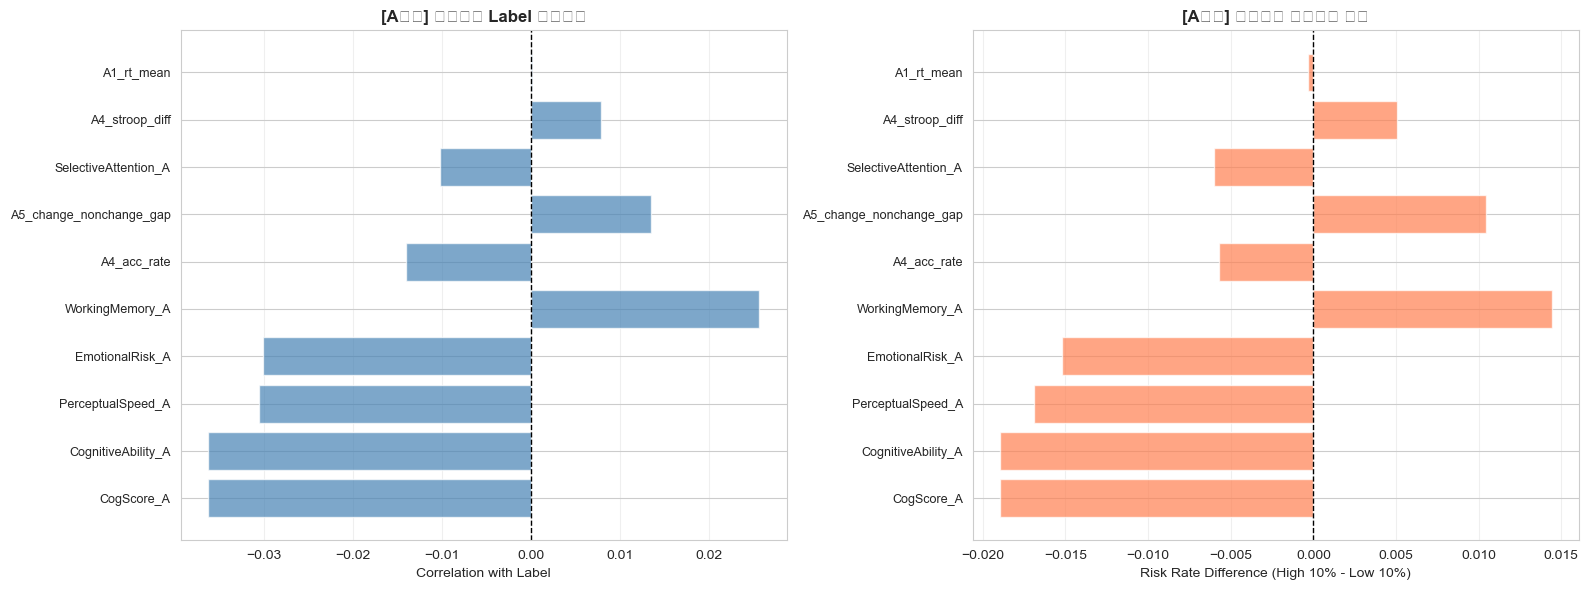


[도메인별 상관관계 및 위험비율 차이]
                   feature  correlation  high_risk_10pct  low_risk_10pct  \
5               CogScore_A      -0.0363           0.0163          0.0353   
3       CognitiveAbility_A      -0.0363           0.0163          0.0353   
0        PerceptualSpeed_A      -0.0306           0.0172          0.0341   
4          EmotionalRisk_A      -0.0301           0.0169          0.0322   
2          WorkingMemory_A       0.0256           0.0328          0.0184   
6              A4_acc_rate      -0.0140           0.0213          0.0271   
9  A5_change_nonchange_gap       0.0135           0.0333          0.0229   
1     SelectiveAttention_A      -0.0103           0.0234          0.0294   
7           A4_stroop_diff       0.0078           0.0282          0.0232   
8               A1_rt_mean       0.0000           0.0272          0.0275   

   risk_diff  
5    -0.0189  
3    -0.0189  
0    -0.0169  
4    -0.0152  
2     0.0144  
6    -0.0057  
9     0.0104  
1    -0.0060  
7    

In [16]:
# ===== A검사 도메인별 위험비율 분석 =====

print("="*80)
print("[A검사] 도메인별 위험비율 분석")
print("="*80 + "\n")

domain_features_A = [
    'PerceptualSpeed_A',
    'SelectiveAttention_A',
    'WorkingMemory_A',
    'CognitiveAbility_A',
    'EmotionalRisk_A',
    'CogScore_A',
    'A4_acc_rate',
    'A4_stroop_diff',
    'A1_rt_mean',
    'A5_change_nonchange_gap'
]

results_A = plot_domain_risk_analysis(
    A_df, 
    domain_features_A, 
    overall_risk=overall_risk,
    title_prefix='[A검사] '
)

if results_A is not None:
    print("\n[도메인별 상관관계 및 위험비율 차이]")
    print(results_A.round(4))


[B검사] 도메인별 위험비율 분석



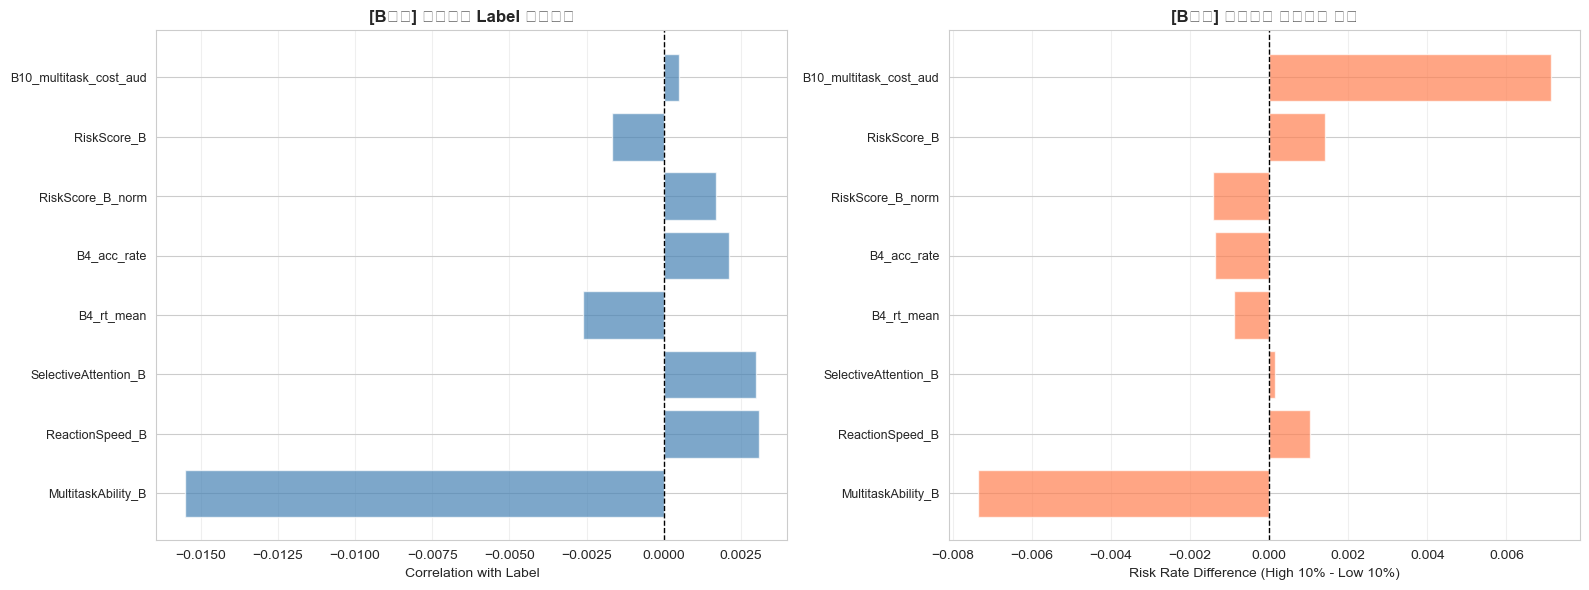


[도메인별 상관관계 및 위험비율 차이]
                  feature  correlation  high_risk_10pct  low_risk_10pct  \
2      MultitaskAbility_B      -0.0155           0.0483          0.0556   
1         ReactionSpeed_B       0.0031           0.0421          0.0411   
0    SelectiveAttention_B       0.0030           0.0414          0.0413   
5              B4_rt_mean      -0.0026           0.0420          0.0429   
4             B4_acc_rate       0.0021           0.0415          0.0429   
3        RiskScore_B_norm       0.0017           0.0402          0.0416   
7             RiskScore_B      -0.0017           0.0416          0.0402   
6  B10_multitask_cost_aud       0.0005           0.0557          0.0486   

   risk_diff  
2    -0.0074  
1     0.0010  
0     0.0001  
5    -0.0009  
4    -0.0014  
3    -0.0014  
7     0.0014  
6     0.0071  


In [17]:
# ===== B검사 도메인별 위험비율 분석 =====

print("="*80)
print("[B검사] 도메인별 위험비율 분석")
print("="*80 + "\n")

domain_features_B = [
    'SelectiveAttention_B',
    'ReactionSpeed_B',
    'MultitaskAbility_B',
    'RiskScore_B_norm',
    'B4_acc_rate',
    'B4_rt_mean',
    'B10_multitask_cost_aud',
    'RiskScore_B'
]

results_B = plot_domain_risk_analysis(
    B_df, 
    domain_features_B, 
    overall_risk=overall_risk,
    title_prefix='[B검사] '
)

if results_B is not None:
    print("\n[도메인별 상관관계 및 위험비율 차이]")
    print(results_B.round(4))


## 10. A vs B 도메인 비교 분석

비슷한 개념의 도메인을 A와 B에서 비교


In [18]:
def compare_domains_A_B(A_df, B_df, A_feature, B_feature, label_col='Label', overall_risk=None):
    """
    A와 B의 비슷한 도메인 비교
    """
    if overall_risk is None:
        overall_risk = A_df[label_col].mean()
    
    results = {}
    
    # A 검사 분석
    if A_feature in A_df.columns:
        A_temp = A_df[[A_feature, label_col]].dropna()
        if len(A_temp) > 0:
            A_corr = A_temp[[A_feature, label_col]].corr().iloc[0, 1]
            A_temp['bin'] = pd.qcut(A_temp[A_feature], q=10, duplicates='drop')
            A_risk_by_bin = A_temp.groupby('bin', observed=True)[label_col].mean()
            A_high_risk = A_risk_by_bin.iloc[-1] if len(A_risk_by_bin) > 0 else np.nan
            A_low_risk = A_risk_by_bin.iloc[0] if len(A_risk_by_bin) > 0 else np.nan
            
            results['A'] = {
                'correlation': A_corr,
                'high_risk_10pct': A_high_risk,
                'low_risk_10pct': A_low_risk,
                'risk_diff': A_high_risk - A_low_risk,
                'mean': A_temp[A_feature].mean(),
                'std': A_temp[A_feature].std()
            }
    
    # B 검사 분석
    if B_feature in B_df.columns:
        B_temp = B_df[[B_feature, label_col]].dropna()
        if len(B_temp) > 0:
            B_corr = B_temp[[B_feature, label_col]].corr().iloc[0, 1]
            B_temp['bin'] = pd.qcut(B_temp[B_feature], q=10, duplicates='drop')
            B_risk_by_bin = B_temp.groupby('bin', observed=True)[label_col].mean()
            B_high_risk = B_risk_by_bin.iloc[-1] if len(B_risk_by_bin) > 0 else np.nan
            B_low_risk = B_risk_by_bin.iloc[0] if len(B_risk_by_bin) > 0 else np.nan
            
            results['B'] = {
                'correlation': B_corr,
                'high_risk_10pct': B_high_risk,
                'low_risk_10pct': B_low_risk,
                'risk_diff': B_high_risk - B_low_risk,
                'mean': B_temp[B_feature].mean(),
                'std': B_temp[B_feature].std()
            }
    
    return results

print("도메인 비교 함수 정의 완료!")


도메인 비교 함수 정의 완료!


In [19]:
# ===== A vs B 도메인 비교 =====

print("="*80)
print("[A vs B] 비슷한 도메인 비교 분석")
print("="*80 + "\n")

# 비교할 도메인 쌍
domain_pairs = [
    ('A4_acc_rate', 'B4_acc_rate', '선택적 주의 (Stroop-like 정확도)'),
    ('A4_stroop_diff', 'B4_rt_mean', '선택적 주의 (Stroop 효과 vs 반응속도)'),
    ('SelectiveAttention_A', 'SelectiveAttention_B', '선택적 주의 Composite Score'),
    ('A1_rt_mean', 'B3_rt_mean', '반응속도 (RT 평균)'),
    ('PerceptualSpeed_A', 'ReactionSpeed_B', '지각/반응 속도 Composite Score'),
]

comparison_results = {}

for A_feat, B_feat, description in domain_pairs:
    print(f"\n{'='*60}")
    print(f"{description}")
    print(f"A: {A_feat} vs B: {B_feat}")
    print(f"{'='*60}")
    
    results = compare_domains_A_B(A_df, B_df, A_feat, B_feat, overall_risk=overall_risk)
    comparison_results[f"{A_feat}_vs_{B_feat}"] = results
    
    if 'A' in results and 'B' in results:
        print(f"\n[A검사] {A_feat}:")
        print(f"  → 상관관계: {results['A']['correlation']:.4f}")
        print(f"  → 위험비율 차이 (상위10%-하위10%): {results['A']['risk_diff']:.4f}")
        print(f"  → 평균: {results['A']['mean']:.4f}, 표준편차: {results['A']['std']:.4f}")
        
        print(f"\n[B검사] {B_feat}:")
        print(f"  → 상관관계: {results['B']['correlation']:.4f}")
        print(f"  → 위험비율 차이 (상위10%-하위10%): {results['B']['risk_diff']:.4f}")
        print(f"  → 평균: {results['B']['mean']:.4f}, 표준편차: {results['B']['std']:.4f}")
        
        # 비교
        print(f"\n[비교]:")
        print(f"  → 상관관계 차이: {abs(results['A']['correlation']) - abs(results['B']['correlation']):.4f}")
        print(f"  → 위험비율 차이 비교: A={results['A']['risk_diff']:.4f} vs B={results['B']['risk_diff']:.4f}")
    elif 'A' in results:
        print(f"\n[A검사만 존재] {A_feat}")
    elif 'B' in results:
        print(f"\n[B검사만 존재] {B_feat}")
    else:
        print(f"\n⚠️  두 피처 모두 없음")

print("\n" + "="*80)
print("✅ A vs B 도메인 비교 완료!")
print("="*80)


[A vs B] 비슷한 도메인 비교 분석


선택적 주의 (Stroop-like 정확도)
A: A4_acc_rate vs B: B4_acc_rate

[A검사] A4_acc_rate:
  → 상관관계: -0.0140
  → 위험비율 차이 (상위10%-하위10%): -0.0057
  → 평균: 0.9862, 표준편차: 0.0214

[B검사] B4_acc_rate:
  → 상관관계: 0.0021
  → 위험비율 차이 (상위10%-하위10%): -0.0014
  → 평균: 0.4749, 표준편차: 0.0721

[비교]:
  → 상관관계 차이: 0.0119
  → 위험비율 차이 비교: A=-0.0057 vs B=-0.0014

선택적 주의 (Stroop 효과 vs 반응속도)
A: A4_stroop_diff vs B: B4_rt_mean

[A검사] A4_stroop_diff:
  → 상관관계: 0.0078
  → 위험비율 차이 (상위10%-하위10%): 0.0051
  → 평균: 18.5096, 표준편차: 33.3476

[B검사] B4_rt_mean:
  → 상관관계: -0.0026
  → 위험비율 차이 (상위10%-하위10%): -0.0009
  → 평균: 0.7867, 표준편차: 0.1781

[비교]:
  → 상관관계 차이: 0.0052
  → 위험비율 차이 비교: A=0.0051 vs B=-0.0009

선택적 주의 Composite Score
A: SelectiveAttention_A vs B: SelectiveAttention_B

[A검사] SelectiveAttention_A:
  → 상관관계: -0.0103
  → 위험비율 차이 (상위10%-하위10%): -0.0060
  → 평균: -0.0000, 표준편차: 1.2340

[B검사] SelectiveAttention_B:
  → 상관관계: 0.0030
  → 위험비율 차이 (상위10%-하위10%): 0.0001
  → 평균: 0.0000, 표준편차: 1.5838

[비교]:
  → 상관관계 차이

## 11. Simple 모델 테스트 (로지스틱 회귀)

도메인 composite score만 사용해서 간단한 모델 테스트


[A검사] Simple 모델 테스트 (도메인 Composite Score만 사용)

사용할 피처 (10개): ['PerceptualSpeed_A', 'SelectiveAttention_A', 'WorkingMemory_A', 'CognitiveAbility_A', 'EmotionalRisk_A', 'Age_num', 'Old_and_low_A4', 'A_low_cog_flag', 'A4_high_stroop_flag', 'A1_slow_rt_flag']

[A검사 Simple 모델 성능]
  → AUC: 0.6602

[Feature Importance (Coefficient)]
                feature  coefficient
5               Age_num       0.4145
3    CognitiveAbility_A      -0.0945
4       EmotionalRisk_A      -0.0819
1  SelectiveAttention_A      -0.0611
0     PerceptualSpeed_A      -0.0536
7        A_low_cog_flag       0.0433
8   A4_high_stroop_flag      -0.0368
2       WorkingMemory_A      -0.0354
9       A1_slow_rt_flag      -0.0229
6        Old_and_low_A4      -0.0003


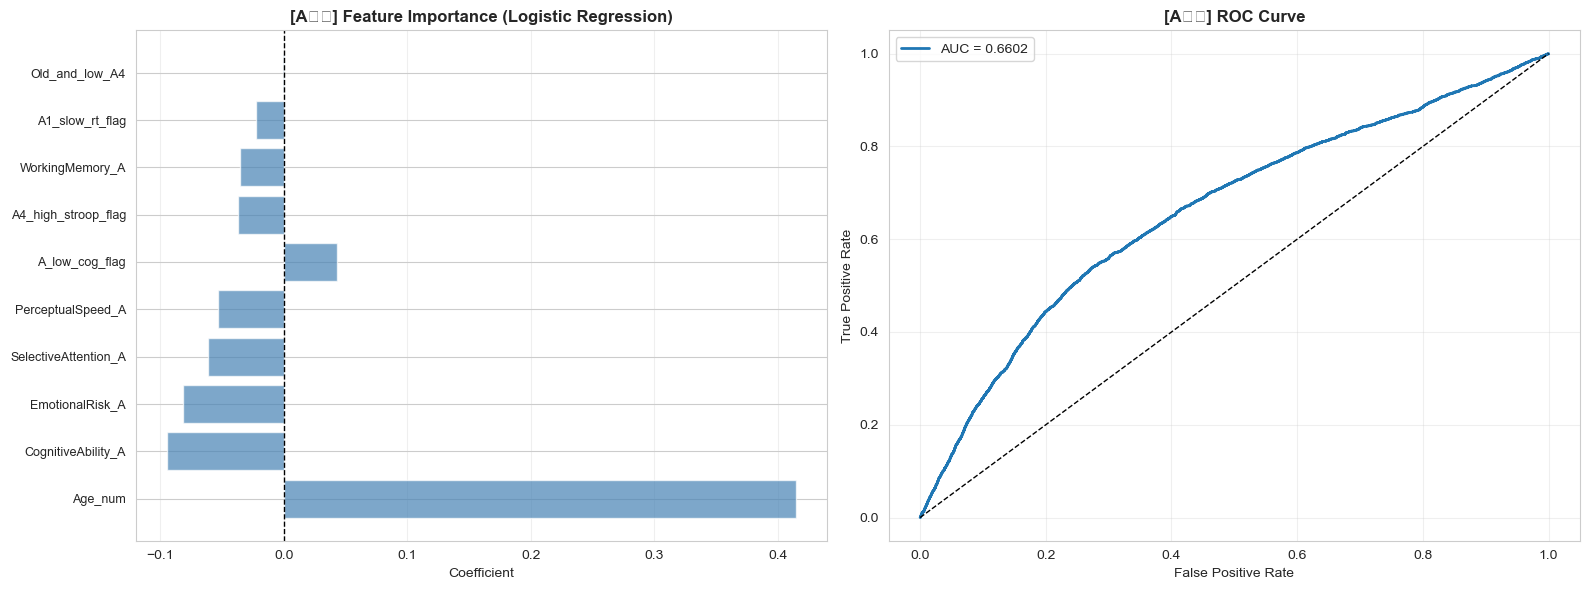

In [20]:
# ===== A검사 Simple 모델 테스트 =====

print("="*80)
print("[A검사] Simple 모델 테스트 (도메인 Composite Score만 사용)")
print("="*80 + "\n")

# 사용할 피처 (도메인 composite score + age + rare flags)
features_A = [
    'PerceptualSpeed_A',
    'SelectiveAttention_A',
    'WorkingMemory_A',
    'CognitiveAbility_A',
    'EmotionalRisk_A',
    'Age_num',
    'Old_and_low_A4',
    'A_low_cog_flag',
    'A4_high_stroop_flag',
    'A1_slow_rt_flag'
]

# 존재하는 피처만 선택
available_features_A = [f for f in features_A if f in A_df.columns]

print(f"사용할 피처 ({len(available_features_A)}개): {available_features_A}")

# 데이터 준비
X_A = A_df[available_features_A].fillna(0)
y_A = A_df['Label']

# Train/Test split
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A
)

# 스케일링
scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled = scaler_A.transform(X_test_A)

# 로지스틱 회귀
lr_A = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_A.fit(X_train_A_scaled, y_train_A)

# 예측
y_pred_proba_A = lr_A.predict_proba(X_test_A_scaled)[:, 1]
auc_A = roc_auc_score(y_test_A, y_pred_proba_A)

print(f"\n[A검사 Simple 모델 성능]")
print(f"  → AUC: {auc_A:.4f}")

# Feature importance (coefficient)
feature_importance_A = pd.DataFrame({
    'feature': available_features_A,
    'coefficient': lr_A.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\n[Feature Importance (Coefficient)]")
print(feature_importance_A.round(4))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficient
x = np.arange(len(feature_importance_A))
axes[0].barh(x, feature_importance_A['coefficient'], color='steelblue', alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_yticks(x)
axes[0].set_yticklabels(feature_importance_A['feature'], fontsize=9)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('[A검사] Feature Importance (Logistic Regression)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_A, y_pred_proba_A)
axes[1].plot(fpr, tpr, label=f'AUC = {auc_A:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('[A검사] ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


[B검사] Simple 모델 테스트 (도메인 Composite Score만 사용)

사용할 피처 (10개): ['SelectiveAttention_B', 'ReactionSpeed_B', 'MultitaskAbility_B', 'RiskScore_B_norm', 'Age_num', 'B4_low_acc_flag', 'B4_slow_rt_flag', 'B_high_risk_flag', 'B10_extreme_multitask_flag', 'Old_and_low_B4']

[B검사 Simple 모델 성능]
  → AUC: 0.5185

[Feature Importance (Coefficient)]
                      feature  coefficient
2          MultitaskAbility_B      -0.0707
8  B10_extreme_multitask_flag       0.0457
4                     Age_num       0.0255
1             ReactionSpeed_B       0.0237
3            RiskScore_B_norm       0.0124
7            B_high_risk_flag       0.0122
0        SelectiveAttention_B       0.0085
6             B4_slow_rt_flag      -0.0073
5             B4_low_acc_flag       0.0070
9              Old_and_low_B4       0.0070


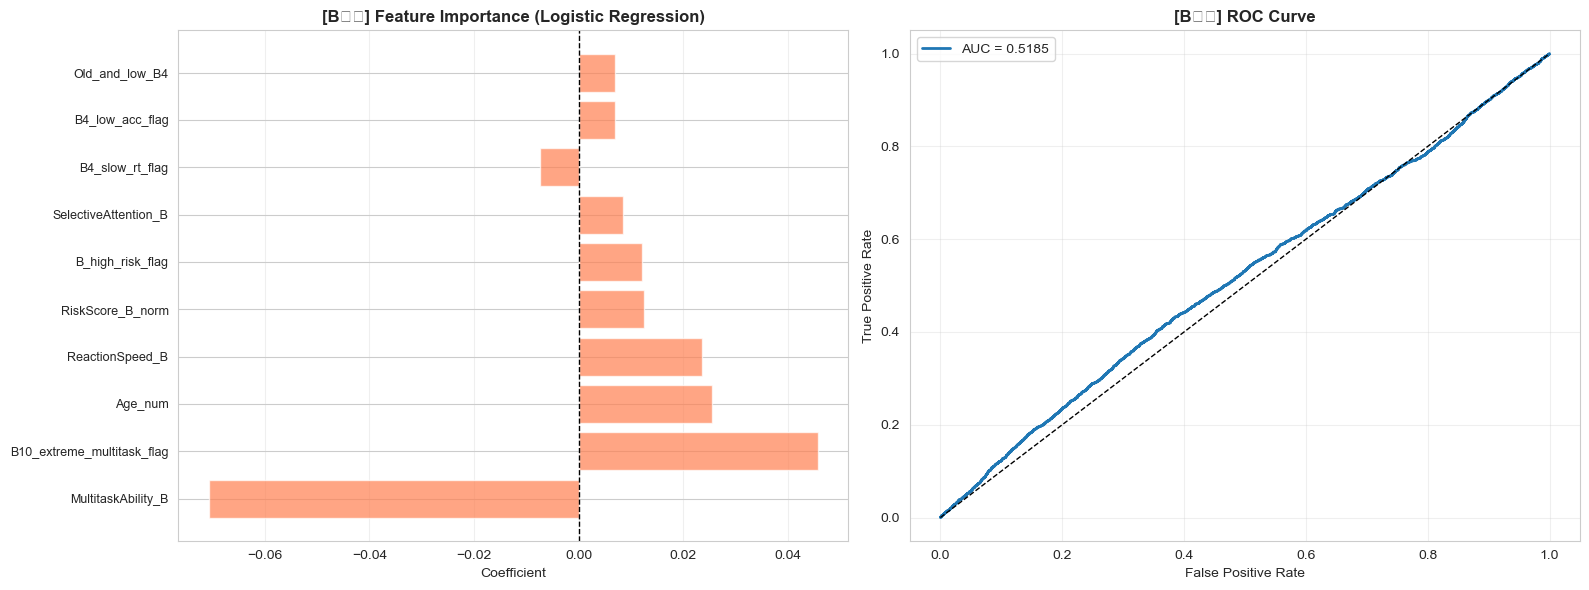

In [21]:
# ===== B검사 Simple 모델 테스트 =====

print("="*80)
print("[B검사] Simple 모델 테스트 (도메인 Composite Score만 사용)")
print("="*80 + "\n")

# 사용할 피처 (도메인 composite score + age + rare flags)
features_B = [
    'SelectiveAttention_B',
    'ReactionSpeed_B',
    'MultitaskAbility_B',
    'RiskScore_B_norm',
    'Age_num',
    'B4_low_acc_flag',
    'B4_slow_rt_flag',
    'B_high_risk_flag',
    'B10_extreme_multitask_flag',
    'Old_and_low_B4'
]

# 존재하는 피처만 선택
available_features_B = [f for f in features_B if f in B_df.columns]

print(f"사용할 피처 ({len(available_features_B)}개): {available_features_B}")

# 데이터 준비
X_B = B_df[available_features_B].fillna(0)
y_B = B_df['Label']

# Train/Test split
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

# 스케일링
scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

# 로지스틱 회귀
lr_B = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_B.fit(X_train_B_scaled, y_train_B)

# 예측
y_pred_proba_B = lr_B.predict_proba(X_test_B_scaled)[:, 1]
auc_B = roc_auc_score(y_test_B, y_pred_proba_B)

print(f"\n[B검사 Simple 모델 성능]")
print(f"  → AUC: {auc_B:.4f}")

# Feature importance (coefficient)
feature_importance_B = pd.DataFrame({
    'feature': available_features_B,
    'coefficient': lr_B.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\n[Feature Importance (Coefficient)]")
print(feature_importance_B.round(4))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficient
x = np.arange(len(feature_importance_B))
axes[0].barh(x, feature_importance_B['coefficient'], color='coral', alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_yticks(x)
axes[0].set_yticklabels(feature_importance_B['feature'], fontsize=9)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('[B검사] Feature Importance (Logistic Regression)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_B, y_pred_proba_B)
axes[1].plot(fpr, tpr, label=f'AUC = {auc_B:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('[B검사] ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 12. 하드코딩용 Threshold 값 출력

모델에서 사용할 수 있도록 threshold 값들을 정리


In [22]:
print("="*80)
print("하드코딩용 Threshold 값 정리")
print("="*80 + "\n")

print("\n[A검사 Threshold 값]")
print("-"*60)

# A4_acc_rate < 0.8
print(f"A4_low_acc_flag: A4_acc_rate < 0.8")

# CogScore_A 하위 25%
if 'CogScore_A' in A_df.columns:
    cog_q25 = A_df['CogScore_A'].quantile(0.25)
    print(f"A_low_cog_flag: CogScore_A < {cog_q25:.6f} (quantile 0.25)")

# A4_stroop_diff 상위 25%
if 'A4_stroop_diff' in A_df.columns:
    stroop_q75 = A_df['A4_stroop_diff'].quantile(0.75)
    print(f"A4_high_stroop_flag: A4_stroop_diff > {stroop_q75:.6f} (quantile 0.75)")

# A1_rt_mean 상위 25%
if 'A1_rt_mean' in A_df.columns:
    rt_q75 = A_df['A1_rt_mean'].quantile(0.75)
    print(f"A1_slow_rt_flag: A1_rt_mean > {rt_q75:.6f} (quantile 0.75)")

# A8_Validity_Score 상위 10%
if 'A8_Validity_Score' in A_df.columns:
    validity_q90 = A_df['A8_Validity_Score'].quantile(0.90)
    print(f"A8_high_validity_flag: A8_Validity_Score > {validity_q90:.6f} (quantile 0.90)")

# A9_Emotional_Score 상위 10%
if 'A9_Emotional_Score' in A_df.columns:
    emotional_q90 = A_df['A9_Emotional_Score'].quantile(0.90)
    print(f"A9_high_emotional_flag: A9_Emotional_Score > {emotional_q90:.6f} (quantile 0.90)")

# Old_and_low_A4: Age>=60 & A4_low_acc_flag
print(f"Old_and_low_A4: Age_num >= 60 & A4_low_acc_flag == 1")

print("\n[B검사 Threshold 값]")
print("-"*60)

# B4_acc_rate < 0.85
print(f"B4_low_acc_flag: B4_acc_rate < 0.85")

# B4_rt_mean 상위 25%
if 'B4_rt_mean' in B_df.columns:
    b4_rt_q75 = B_df['B4_rt_mean'].quantile(0.75)
    print(f"B4_slow_rt_flag: B4_rt_mean > {b4_rt_q75:.6f} (quantile 0.75)")

# RiskScore_B 상위 25%
if 'RiskScore_B' in B_df.columns:
    risk_q75 = B_df['RiskScore_B'].quantile(0.75)
    print(f"B_high_risk_flag: RiskScore_B > {risk_q75:.6f} (quantile 0.75)")

# B10_multitask_cost_aud 극단값 (상위 5% 또는 하위 5%)
if 'B10_multitask_cost_aud' in B_df.columns:
    cost_q95 = B_df['B10_multitask_cost_aud'].quantile(0.95)
    cost_q05 = B_df['B10_multitask_cost_aud'].quantile(0.05)
    print(f"B10_extreme_multitask_flag: B10_multitask_cost_aud > {cost_q95:.6f} (quantile 0.95) OR < {cost_q05:.6f} (quantile 0.05)")

# Old_and_low_B4: Age>=60 & B4_low_acc_flag
print(f"Old_and_low_B4: Age_num >= 60 & B4_low_acc_flag == 1")

print("\n" + "="*80)
print("✅ Threshold 값 정리 완료!")
print("="*80)


하드코딩용 Threshold 값 정리


[A검사 Threshold 값]
------------------------------------------------------------
A4_low_acc_flag: A4_acc_rate < 0.8
A_low_cog_flag: CogScore_A < 25.000000 (quantile 0.25)
A4_high_stroop_flag: A4_stroop_diff > 38.375000 (quantile 0.75)
A1_slow_rt_flag: A1_rt_mean > 20.555556 (quantile 0.75)
A8_high_validity_flag: A8_Validity_Score > 12.000000 (quantile 0.90)
A9_high_emotional_flag: A9_Emotional_Score > 39.000000 (quantile 0.90)
Old_and_low_A4: Age_num >= 60 & A4_low_acc_flag == 1

[B검사 Threshold 값]
------------------------------------------------------------
B4_low_acc_flag: B4_acc_rate < 0.85
B4_slow_rt_flag: B4_rt_mean > 0.839333 (quantile 0.75)
B_high_risk_flag: RiskScore_B > 0.412816 (quantile 0.75)
B10_extreme_multitask_flag: B10_multitask_cost_aud > 0.050000 (quantile 0.95) OR < -0.112500 (quantile 0.05)
Old_and_low_B4: Age_num >= 60 & B4_low_acc_flag == 1

✅ Threshold 값 정리 완료!
